<a href="https://colab.research.google.com/github/adan-data/Portfolio/blob/All-Projects/Real_Time_News_Data_Collection_using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

As a Data Scientist, having the ability to collect, process, and analyze live news data is a seriously valuable skill. It covers everything from querying live news APIs to extracting and storing the data.

Real-Time News Data Collection using Python
Before you begin, make sure you have:

1. Your NewsAPI key (get it for free at newsapi.org)
2. The following Python libraries:

pip install dotenv wordcloud

In [ ]:
!pip install dotenv wordcloud

Step 1: Fetch Live News Using NewsAPI
Let’s set up our script. Most of the data professionals use NewsAPI because it gives them programmatic access to news from thousands of sources. Think of it as a news search engine.

Here’s the function we can use to fetch news headlines:

In [ ]:
from google.colab import userdata

API_KEY = userdata.get('NEWS_API_KEY')
if API_KEY is None:
  print("Error: NEWS_API_KEY not found in Colab secrets. Please add it.")
else:
  print("API key loaded successfully.")

API key loaded successfully.


In [ ]:
import requests
import pandas as pd
from datetime import datetime, timedelta
# from dotenv import load_dotenv # Removed dotenv
import os

# load API key from .env file # Removed dotenv load
# load_dotenv()
# API_KEY = os.getenv("NEWS_API_KEY") # Assuming the API key is stored in a .env file with the key NEWS_API_KEY # Removed dotenv get

# dates for the last 2 days
to_date = datetime.utcnow().date()
from_date = to_date - timedelta(days=2)

QUERY = 'India Pakistan war OR conflict OR border OR attack OR tension'
LANG = 'en'
PAGE_SIZE = 100  # max per page

def fetch_news(query, from_date, to_date, api_key, page_size=100):
    url = 'https://newsapi.org/v2/everything'
    all_articles = []
    for page in range(1, 6):  # try up to 5 pages
        params = {
            'q': query,
            'from': from_date,
            'to': to_date,
            'language': LANG,
            'pageSize': page_size,
            'page': page,
            'sortBy': 'publishedAt',
            'apiKey': api_key # Pass the API key here
        }
        response = requests.get(url, params=params)
        data = response.json()

        if data.get("status") != "ok":
            print("Error:", data.get("message"))
            break

        articles = data.get("articles", [])
        if not articles:
            break
        all_articles.extend(articles)
    return all_articles

Here, we are querying up to 500 articles from the past two days. As a student, you can only use the free API, which gives you access to up to 100 news articles.

Step 2: Store the News Articles in a

Now, we will convert the API output into a structured format (a DataFrame) and save it in a way that can be used for analysis:



In [ ]:
# fetch articles
articles = fetch_news(QUERY, from_date.isoformat(), to_date.isoformat(), API_KEY)

# convert to dataframe
df = pd.DataFrame([{
    'title': article['title'],
    'description': article['description'],
    'source': article['source']['name'],
    'published_at': article['publishedAt'],
    'url': article['url'],
    'content': article['content']
} for article in articles])

# save to CSV
df.to_csv("india_pakistan_conflict_news.csv", index=False)
print(f"{len(df)} articles saved to 'india_pakistan_conflict_news.csv'")

Error: You have requested too many results. Developer accounts are limited to a max of 100 results. You are trying to request results 100 to 200. Please upgrade to a paid plan if you need more results.
59 articles saved to 'india_pakistan_conflict_news.csv'


At this point, we’ve successfully built a pipeline that pulls in structured news data on demand. If you want to automate this, you can schedule it with Python’s schedule module

Step 3: Visualizing the Headlines with a Word Cloud

One of my favourite ways to quickly gauge what a collection of articles is about is with a word cloud. Here’s how you can generate one using titles and descriptions:

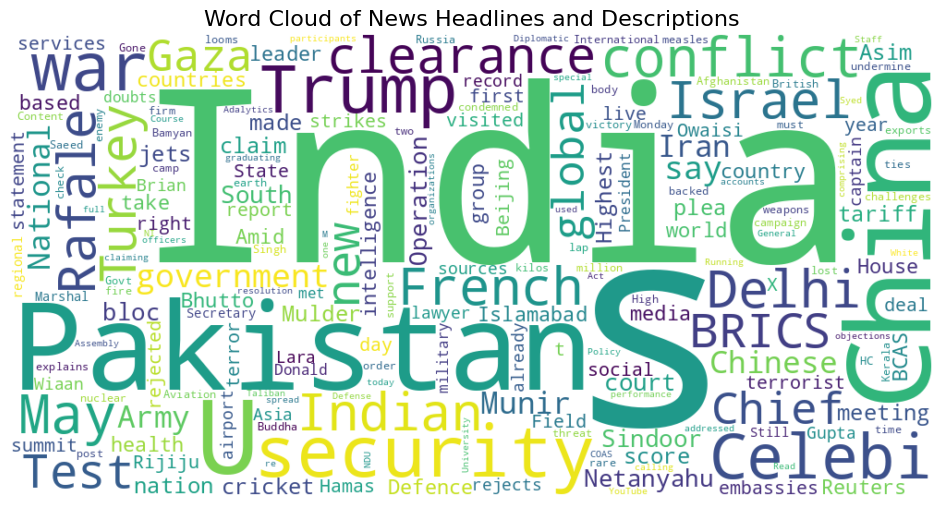

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# combine title and description text for word cloud
text_data = df['title'].fillna('') + ' ' + df['description'].fillna('')
combined_text = ' '.join(text_data.tolist())

# generate word cloud
wordcloud = WordCloud(width=1000, height=500, background_color='white', collocations=False).generate(combined_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of News Headlines and Descriptions", fontsize=16)
plt.show()

Building tools like this not only sharpens your data collection skills but also prepares you for advanced projects in NLP, dashboards, or even ML-powered event prediction systems.

Summary

So, as a Data Scientist, having the ability to collect, process, and analyze live news data is a seriously valuable skill. It covers everything from querying live news APIs to extracting and storing the data.